# POLISCI 3

## Week 11 Notebook Lecture 1: Visualizing Data

Welcome to Week 11!

For the next (and last) few weeks of the class, we'll be learning more tools for **examining relationships between variables** in datasets.

Because this is often easiest to do in R, we'll use **two Notebook Lectures** this week (this one and Notebook Lecture 2, which we'll do next).  There is not a pdf slide deck this week.

I'll will cover any material we don't get to in a recording, if necessary.

### New R tools for summarizing relationships between variables

So far, we've learned some R tools for summarizing relationships between variables:
- `table()`, which worked well for two categorical variables (e.g., rich, middle-income, and poor countries) but broke down with continuous data or with more than one category
- `difference_in_means()`, which is limited to looking at differences between two groups

We also learned about 
- how to assess the correlation between two variables using `cor()`; and
- how to plot distributions of data using tools like `hist()` or `histogram()` and `plot()`.

This week, however, we're going to learn some more tools for summarizing relationship between variables that are inherently continuous, like average lifespans in a country and that country's average income. 

In particular, we will learn about how to run and interpret a **bivariate regression**, that is, a regression with just two variables. 

(Next week, we will consider multivariate regression, where there are more variables).

### Why is this important?

Methods for examining relationships between variables are crucial both for assessing both **causal** and **descriptive** hypotheses.  

So far, we've talked a lot in the class about **causal hypotheses** and ways to test them.  

But many important relationships are simply **descriptive**.  Sometimes, it's very useful to summarize the relationship between two variables, even if we don't necessarily think that one causes the other.

Note that makes an analysis causal or descriptive is not the technique used to analyze the data. Rather, inferring causation successfully depends on features of the **research design.**  

For example, you could ask questions like this:
- is there a treatment variable that is assigned randomly, like in a randomized experiment?
- If not, can we make a compelling claim that assignment is as-if random?
- Or do other features design allow for a causal interpretation if certain assumptions are met, like in a difference-in-differences analysis? 

We can sometimes make persuasive causal inferences even in the absence of such designs, but it gets much harder because the number of **alternative explanations** for any particular finding is often much larger.

We'll return to these points again.  For now, we just want to talk about some more techniques we can use to summarize relationships between two variables.



One of the most important points about data analysis is that we must **look at our data.** 

Why? Often, patterns are apparent visually that statistics don't make immediately obvious. 

For example, this data shown in each of these pictures is actually identical on common statistics we're going to discuss further the next few weeks.

<img src="same-stats-different-graphs-image-1920x1000.gif">

But looking at the plots visually, the data are really different in each of these pictures!

Therefore, when dealing with descriptive data about relationships between two variables, I always recommend plotting your data first.

This turns out to be _super_ easy in R!  

We already learned some great tools in "base R" to look at data visually, for example, `plot()` and `hist()`. 

Here, we are going to learn a **few more tools** that are available in R packages to help us visualize data.

- A side note: when I say "base R," I mean functions or routines that are available with a basic distribution of R. This is contrasted with the functions or routines available in specialized packages that people have written for R, such as the `difference_in_means()` function in the package `estimatr()`).  

- R is a (mostly) "open-source" language.  That means social scientists and computer programmers write and maintain packages that they make **freely available**. That's great for open science!


### This week's data: politicians' perceptions of their constituents

This week's data is from Broockman and Skovron (2018)'s <a href="https://www.cambridge.org/core/journals/american-political-science-review/article/abs/bias-in-perceptions-of-public-opinion-among-political-elites/2EF080E04D3AAE6AC1C894F52642E706">study</a> of 3,765 US state legislators' perceptions of constituency opinion on several issues. The authors compared legislators' perceptions of their constituents with measures of their constituents' _actual_ opinions.

Let's take a look at the data:

In [19]:
# RUN THIS CELL
options(warn = -1) # suppress warnings

data <- read.csv('broockman_skovron.csv')
head(data)

,republican,incumbent,marriage_perception,marriage_opinion,religexempt_perception,religexempt_opinion,gunsbanassault_perception,gunsbanassault_opinion
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,0,50,69,60,34,70,70
2,1,0,10,48,60,49,10,46
3,1,1,25,53,65,46,NA,58
4,0,0,50,67,30,38,NA,70
5,1,0,25,52,70,44,NA,60
6,0,1,NA,71,NA,35,NA,69


Here is an overview of what the columns in the dataset represent: 

- `republican`: whether the state legislator or state legislative candidate who answered the survey was a Republican (1 = Republican, 0 = Democrat)
- `incumbent`: whether the person who answered the survey was an incumbent representative (i.e., currently holds political office) (1 = already holds office, 0 = just a candidate)
- `marriage_perception`: what percent of the politician's constituents they think support same-sex marriage
- `marriage_opinion`: what percent of the politician's constituents actually support same-sex marriage
- `religexempt_perception`: what percent of the politician's constituents they think support allowing employers to refuse to cover birth control for employees if it violates their religious beliefs
- `religexempt_opinion`: what percent of the politician's constituents actually support allowing employers to refuse to cover birth control for employees if it violates their religious beliefs
- `gunsbanassault_perception`: what percent of the politician's constituents they think support banning assault weapons
- `gunsbanassault_opinion`: what percent of the politician's constituents actually support banning assault weapons

### Making plots 

The most common software package for making graphics in R is called `ggplot2`.  This is more powerful and flexible than the base R functions like `plot()` that we used earlier in the class (though `plot()` is also useful, and sometimes it is all you need!).

`ggplot2` is really powerful and has a lot of complex features. 

For example, `ggplot2` makes it easy to create one graph (like a scatterplot) and then add another feature to it (like a line of best fit).  We'll see this later in this lecture!

We'll start by using `ggplot1` to make a scatterplot between two variables, which we also learned to do earlier in the semester using `plot()`. Reminder: in a scatterplot, every observation gets a single point on a graph so that you can visualize the relationship between two variables.

Before I start making graphs, a reminder on a bit of jargon:
- the horizontal axis of a graph that runs left to right is called the x-axis; and
- the vertical axis of a graph that runs from top to bottom is called the y-axis.

In `ggplot2`, we make simple scatterplots like this: 

`qplot(x.axis.var.name, y.axis.var.name, data = dataset.name)`.

**Note (useful for the in-class activity!):** if we want to change the dataset we are looking at, just change what comes after `data =` to give `qplot()` a different dataset. For example, we could write something like:

```
subset.name <- subset(dataset.name, variable.to.subset.on == 1)
qplot(x.axis.var.name, y.axis.var.name, data = subset.name)
```

Let's start by creating a **scatterplot** between `marriage_perception` and `marriage_opinion`.

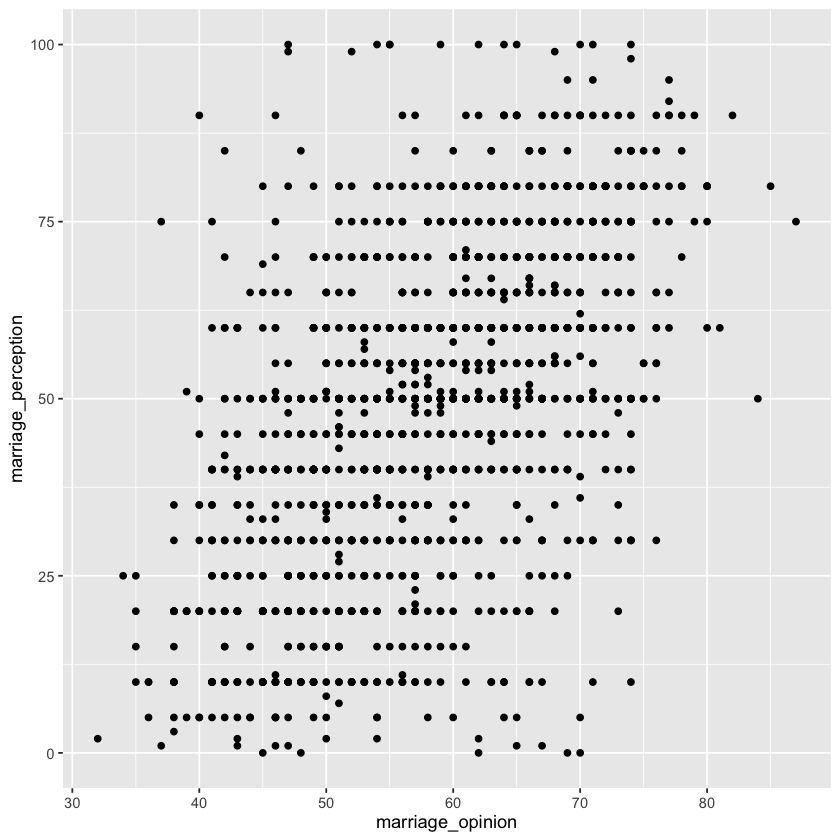

In [17]:
library(ggplot2) # Read in the ggplot2 library. I'll do this at the top of every file.

our.first.plot <- qplot(marriage_opinion, marriage_perception, data = data)
our.first.plot

What a nice-looking plot!

We can already see some pretty interesting things.
- You can see lines of data at intervals of 5 or so. That's because the politicians tend to round to 5 when they name numbers in the 0-100 range.
- It looks like politicians are underestimating support for same-sex marriage.

To understand this second thing, what our eye is trying to do is figure out what the average of the y variable (perception) is at a given level of the x variable (opinion).

We can visualize this too, by adding a **line of best fit**. (We'll talk more about what this line is in Notebook Lecture 2!). 

We do this by adding `+ geom_smooth(method = 'lm')` right after the code to make the main graph, like this:

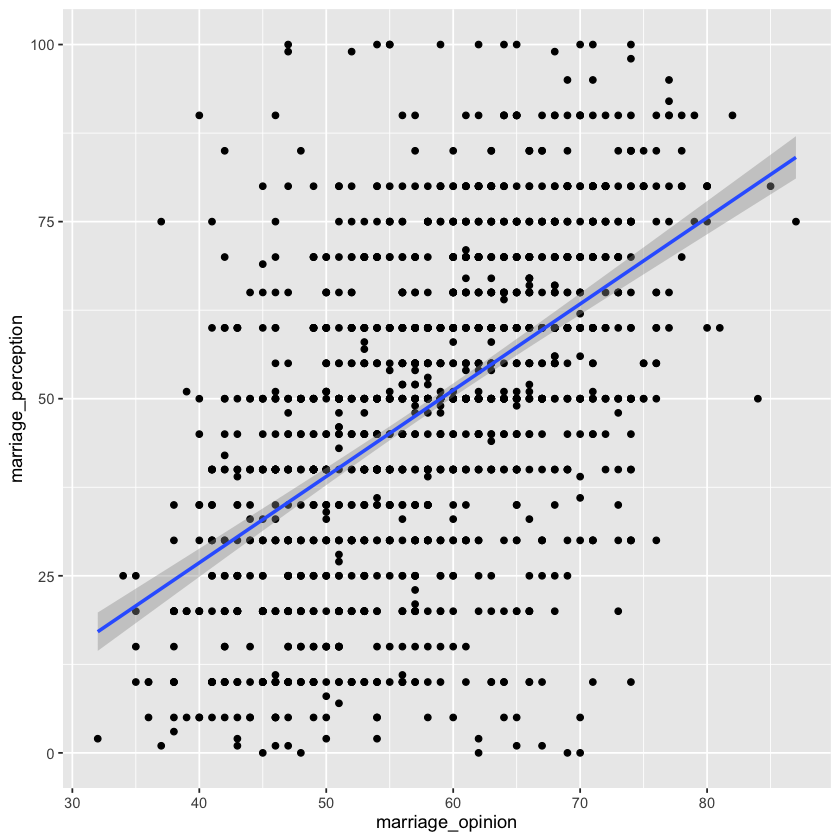

In [18]:
plot.with.lm <- qplot(marriage_opinion, marriage_perception, data = data) + geom_smooth(formula = y~x, method = 'lm')
plot.with.lm

**The line of best fit gives us the best guess for the y variable given a value of the x variable.** So, we use the line of best fit to take an x value and then figure out what our best guess for y should be, given that value of x.

For example, given marriage opinion is at 60% support, politicians' average guess is at about 50% -- much lower! So what we can now see is that politicians underestimate support for same-sex marriage by about 10 percentage points.

Looking at a graph is a really natural way to see this, and much more powerful than just understanding this with numbers.

In the next Notebook Lecture this week, we'll learn more about this **line of best fit** -- which is also called the **bivariate regression** line.